In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

# Mutual Fund Analytics

## Exploratory Data Analysis (EDA)

### Bluestock Fintech Data Analytics Internship

This notebook contains the Exploratory Data Analysis (EDA) for the Mutual Fund Analytics Capstone Project. The objective is to analyze trends, fund performance, investor behaviour, portfolio allocation, and generate business insights using Python visualization libraries.

In [2]:
# Load all required datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
# Display the shape of all datasets

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP Inflows": sip,
    "Category Inflows": category,
    "Folio Count": folio,
    "Scheme Performance": performance,
    "Investor Transactions": transactions,
    "Portfolio Holdings": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:25} {df.shape}")

Fund Master               (40, 15)
NAV History               (46000, 3)
AUM                       (90, 5)
SIP Inflows               (48, 6)
Category Inflows          (144, 3)
Folio Count               (21, 6)
Scheme Performance        (40, 19)
Investor Transactions     (32778, 13)
Portfolio Holdings        (322, 8)
Benchmark                 (8050, 3)


## 1. NAV Trend Analysis

This analysis visualizes the daily Net Asset Value (NAV) trends of all mutual fund schemes from 2022 to 2026. The chart also highlights the 2023 bull market and the 2024 market correction.

In [4]:
# Preview NAV dataset

nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
# Convert date column to datetime

nav_history["date"] = pd.to_datetime(nav_history["date"])

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [6]:
# Merge scheme names
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Ensure date column is datetime
nav_plot["date"] = pd.to_datetime(nav_plot["date"])

# Create Plotly line chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0
)

# Add annotation above the plot
fig.add_annotation(
    x=pd.Timestamp("2023-07-01"),
    y=1.15,
    xref="x",
    yref="paper",
    text="<b>2023 Bull Run</b>",
    showarrow=False,
    font=dict(size=14, color="green")
)

fig.add_annotation(
    x=pd.Timestamp("2024-07-01"),
    y=1.15,
    xref="x",
    yref="paper",
    text="<b>2024 Market Correction</b>",
    showarrow=False,
    font=dict(size=14, color="red")
)

# Improve layout
fig.update_layout(
    template="plotly_white",
    height=900,
    width=1200,
    margin=dict(t=120, l=70, r=50, b=180),
    legend=dict(
        orientation="h",
        y=-0.35,
        x=0,
        title="Scheme"
    ),
    title_x=0.5
)

fig.show()

### Insight 1

The daily NAV trend shows a steady increase across most mutual fund schemes from 2022 to 2026. During 2023, many equity-oriented funds experienced consistent growth, reflecting the market's bullish momentum. A comparatively slower growth phase is visible during 2024, representing the market correction period before recovery resumed in 2025.

# Task 2 - AUM Growth Analysis (2022–2025)

This analysis compares the Assets Under Management (AUM) of different fund houses from 2022 to 2025 using a grouped bar chart. The visualization highlights the growth trend across years and emphasizes SBI Mutual Fund's market leadership.

In [7]:
# Load AUM dataset

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [8]:
# Prepare AUM data

aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Keep only 2022-2025
aum_filtered = aum[
    aum["year"].between(2022, 2025)
]

print(aum_filtered.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


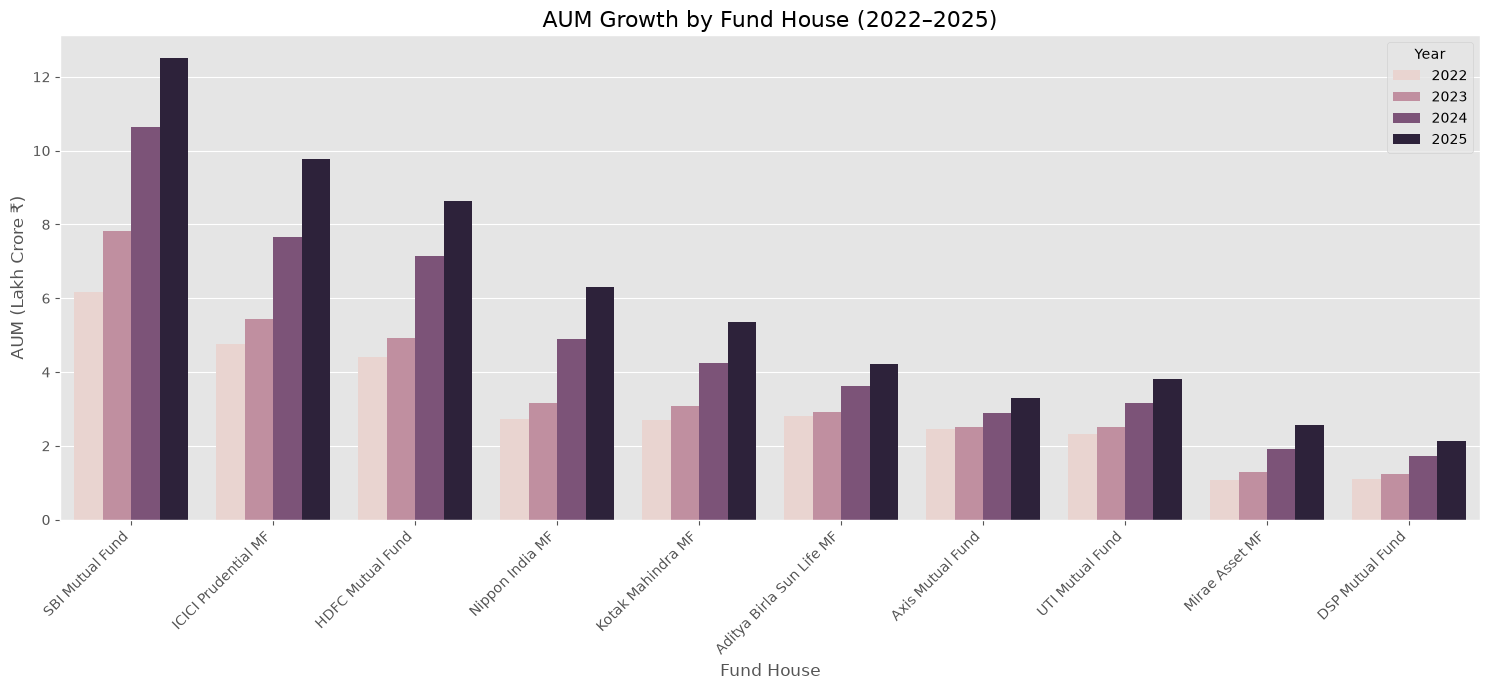

In [9]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum_filtered,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    errorbar=None
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")

plt.tight_layout()

plt.show()

### Insight 2

SBI Mutual Fund consistently recorded the highest Assets Under Management (AUM) from 2022 to 2025. Its AUM increased from approximately ₹6.2 lakh crore in 2022 to around ₹12.5 lakh crore in 2025, demonstrating strong market leadership and sustained investor confidence. Other major fund houses, including ICICI Prudential Mutual Fund and HDFC Mutual Fund, also showed steady growth during the same period.

# Task 3 – Monthly SIP Inflow Trend (2022–2025)

This visualization shows the monthly SIP inflows from January 2022 to December 2025. It highlights the continuous increase in retail participation in mutual funds and marks the all-time high SIP inflow recorded in December 2025.

In [10]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [11]:
# Convert month column to datetime

sip["month"] = pd.to_datetime(sip["month"])

# Verify data types
sip.dtypes

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object

In [12]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=6)
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    title_x=0.5,
    template="plotly_white",
    width=1200,
    height=600
)

# Highlight Dec 2025 all-time high

highest = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-60,
    bgcolor="yellow"
)

fig.show()

### Insight 3

Monthly SIP inflows increased steadily from January 2022 to December 2025, reflecting consistent growth in retail investor participation. The highest monthly SIP inflow of **₹31,002 crore** was recorded in **December 2025**, indicating strong investor confidence and continued expansion of systematic investments in mutual funds.

# Task 4 – Category Inflow Heatmap

This heatmap visualizes monthly net inflows across different mutual fund categories. Darker shades represent higher inflows, making it easier to identify periods of strong investor interest in specific fund categories.

In [13]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [14]:
category["month"] = pd.to_datetime(category["month"])

category["month_label"] = category["month"].dt.strftime("%b-%y")

category[["month", "month_label"]].head()

,month,month_label
0,2024-04-01,Apr-24
1,2024-04-01,Apr-24
2,2024-04-01,Apr-24
3,2024-04-01,Apr-24
4,2024-04-01,Apr-24


In [15]:
heatmap_data = category.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

heatmap_data

month_label,Apr-24,Aug-24,Dec-24,Feb-25,Jan-25,Jul-24,Jun-24,Mar-25,May-24,Nov-24,Oct-24,Sep-24
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0
Large Cap,2413.0,1940.0,1923.0,1925.0,2025.0,2574.0,2519.0,2234.0,2076.0,1870.0,2255.0,1879.0
Liquid,37537.0,41952.0,34933.0,32374.0,33892.0,34643.0,40486.0,38681.0,41872.0,40506.0,39091.0,35308.0
Mid Cap,3897.0,3899.0,5023.0,4819.0,4316.0,4548.0,5047.0,5061.0,5300.0,4336.0,4106.0,4960.0
Sectoral/Thematic,8052.0,8360.0,9820.0,9215.0,7893.0,9896.0,10030.0,8614.0,8354.0,7397.0,7680.0,8518.0


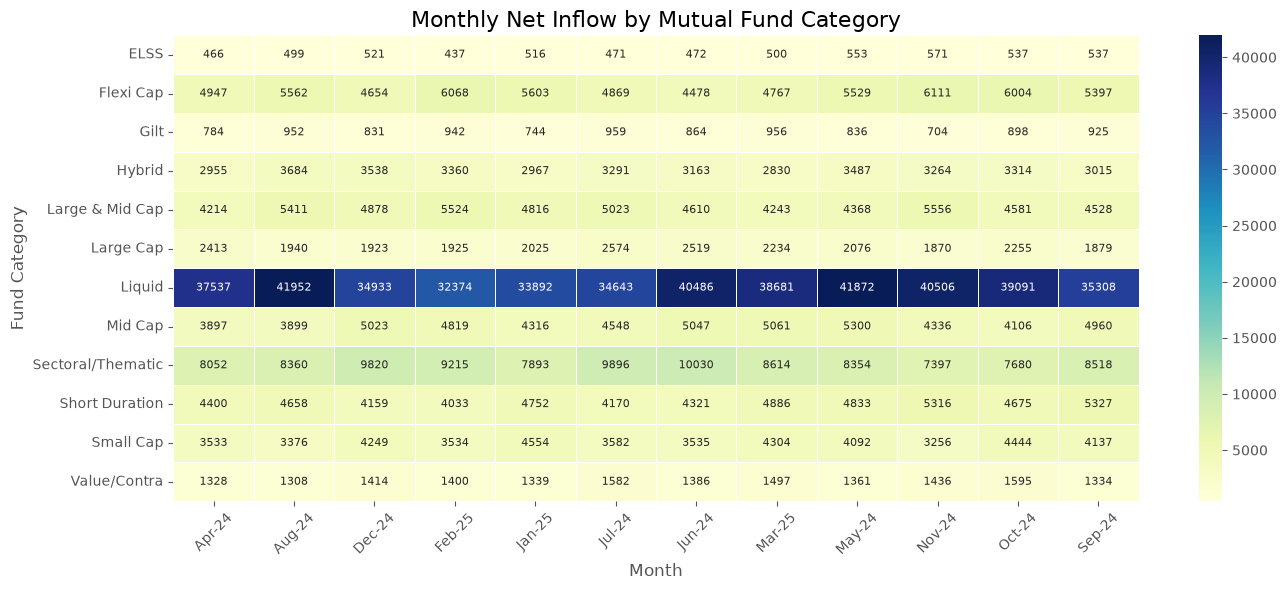

In [16]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title("Monthly Net Inflow by Mutual Fund Category", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 4

The heatmap indicates that Liquid Funds dominated monthly net inflows across the observed period. Flexi Cap and Sectoral/Thematic funds also attracted strong investor interest, whereas ELSS, Gilt, and Value/Contra categories maintained comparatively lower but stable inflows.

# Task 5 – Investor Demographics

This section analyzes investor demographics using age groups, gender distribution, and SIP investment behavior. The visualizations help identify the dominant investor segments and compare investment patterns across different age groups.

In [17]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [18]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

## Age Group Distribution

This chart shows the proportion of investors across different age groups.

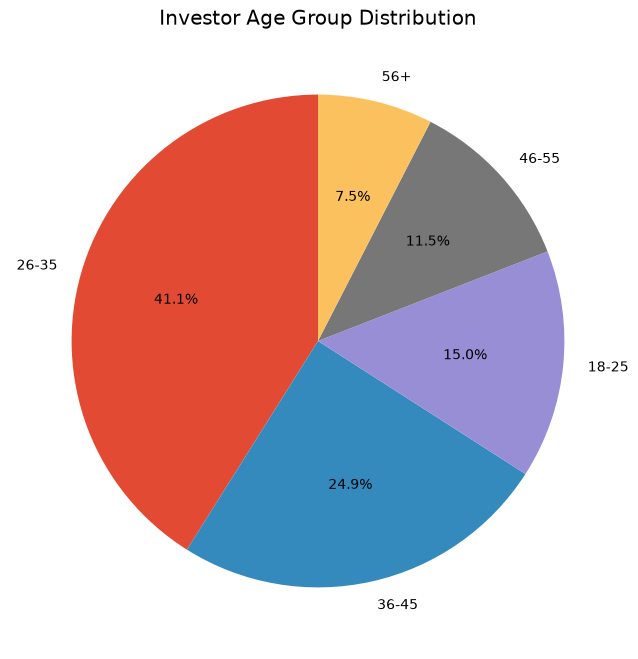

In [19]:
# Count investors by age group

age_distribution = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5.1

The investor base is well distributed across different age groups, with the highest participation coming from the working-age population. This indicates that mutual funds are widely adopted by investors during their prime earning years.

## SIP Amount by Age Group

This box plot compares SIP investment amounts across different age groups.

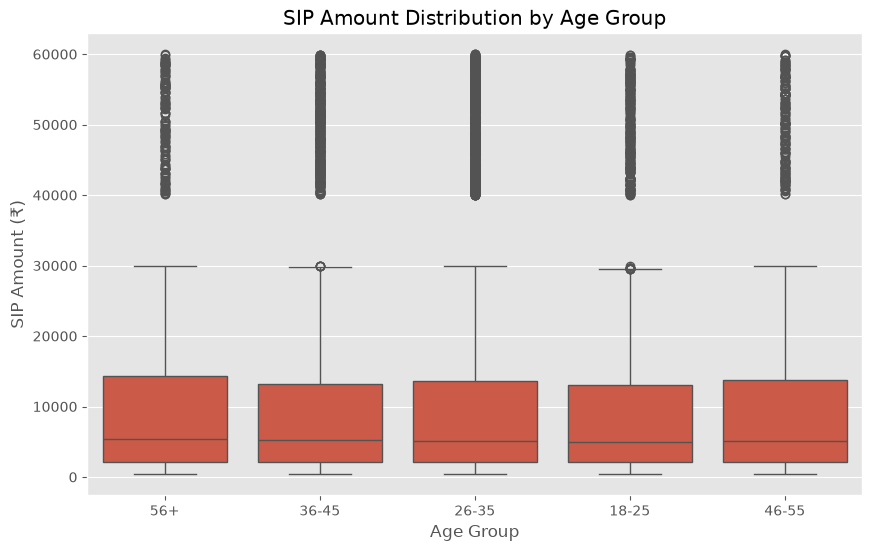

In [20]:
# Filter only SIP transactions

sip_data = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "../reports/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5.2

The box plot shows variation in SIP investment amounts across age groups. Middle-aged investors generally contribute higher SIP amounts, while younger investors exhibit lower median investments with greater variability.

## Gender Distribution

This chart illustrates the gender-wise distribution of investors.

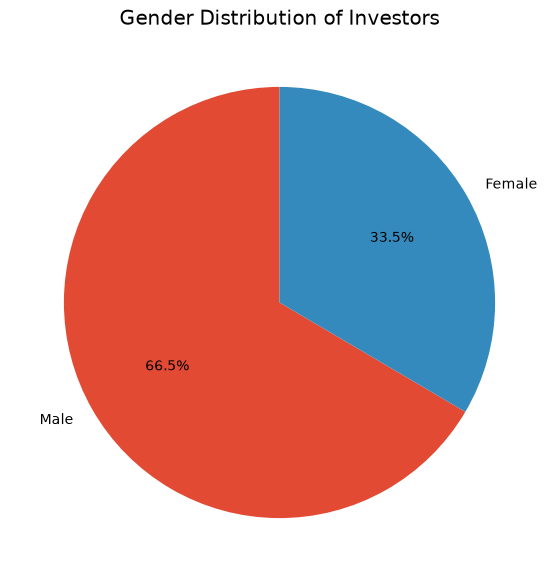

In [21]:
gender_distribution = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_distribution,
    labels=gender_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5.3

The gender distribution highlights investor participation across male and female investors. The chart provides a quick overview of demographic diversity within the mutual fund investor base.

# Task 6 – Geographic Distribution

This section analyzes the geographical distribution of mutual fund investments across Indian states and compares investor participation between T30 (Top 30) and B30 (Beyond Top 30) cities.

In [22]:
# Filter only SIP transactions

sip_state = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
]

# Total SIP amount by state

state_sip = (
    sip_state.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

state_sip.tail()

state
Gujarat           18378904
Tamil Nadu        18404368
Telangana         18620216
Punjab            20140064
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64

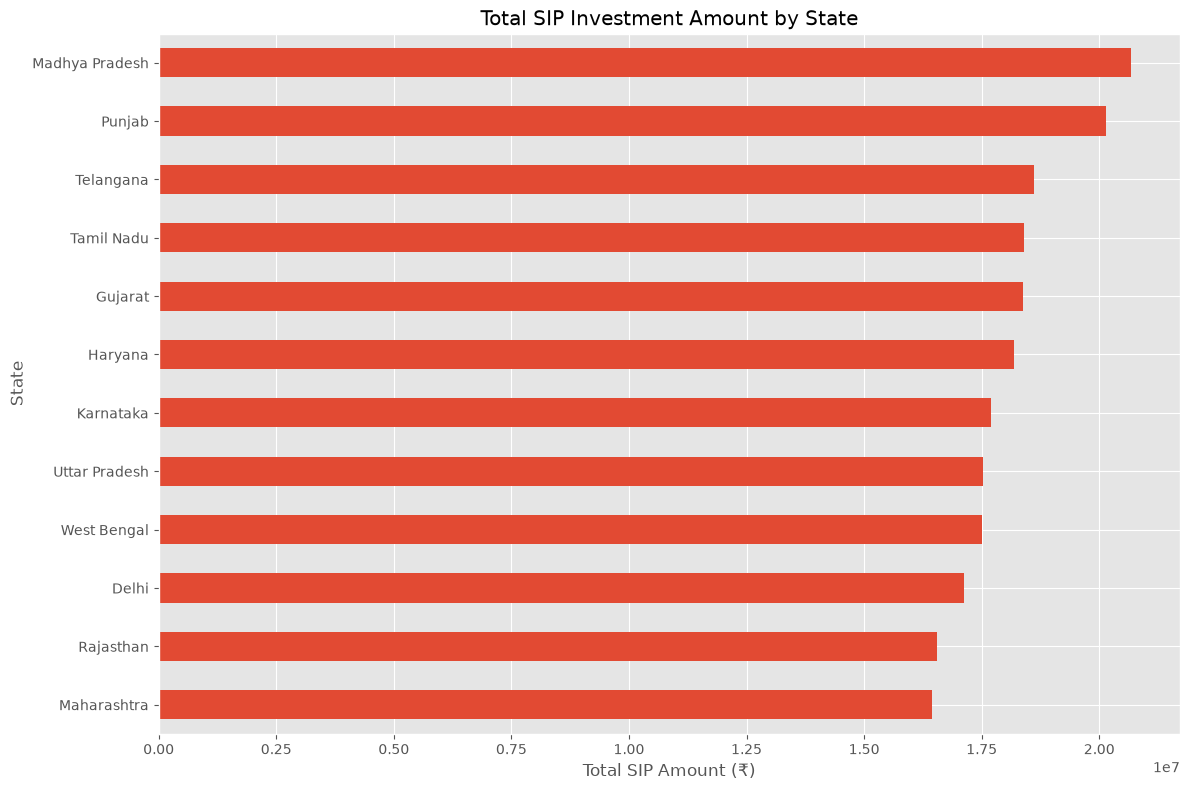

In [23]:
plt.figure(figsize=(12,8))

state_sip.plot(
    kind="barh"
)

plt.title("Total SIP Investment Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6.1

The geographical analysis shows that SIP investments are distributed across multiple states, with a few states contributing significantly higher investment amounts. This reflects stronger mutual fund participation in economically active regions.

In [24]:
city_tier = transactions["city_tier"].value_counts()

city_tier

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

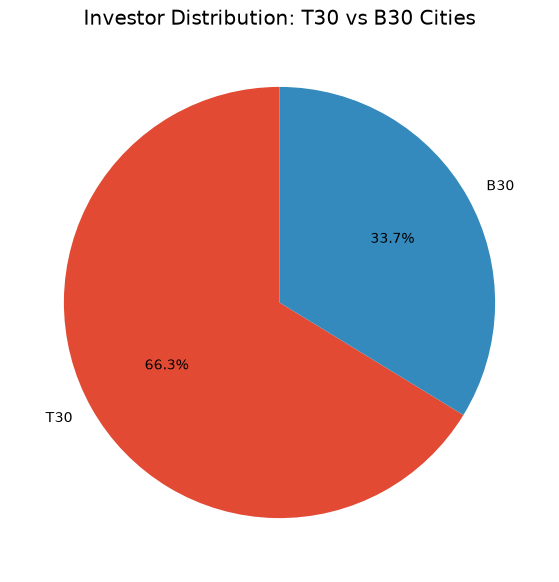

In [25]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.savefig(
    "../reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6.2

The comparison between T30 and B30 cities highlights the geographical spread of mutual fund investors. While T30 cities contribute a significant share of investments due to higher urban participation, B30 cities also represent a substantial investor base, reflecting the expanding reach of mutual fund investments across India.

# Task 7 – Mutual Fund Folio Count Growth

This chart illustrates the growth in mutual fund folio counts from January 2022 to December 2025. It highlights the increasing participation of investors in mutual funds over time.

In [26]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [27]:
# Convert month column to datetime

folio["month"] = pd.to_datetime(folio["month"])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


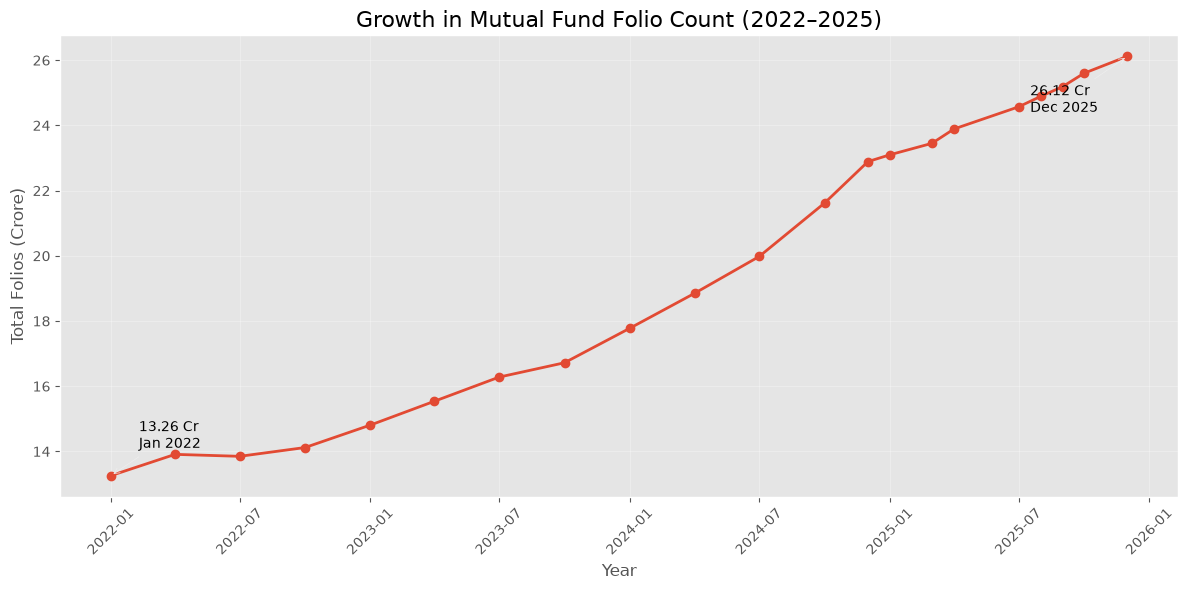

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# First milestone
plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Last milestone
plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(-70,-40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 7

The total number of mutual fund folios increased from **13.26 crore in January 2022** to **26.12 crore by December 2025**, nearly doubling over the four-year period. This sustained growth reflects rising investor participation, greater financial awareness, and increasing adoption of mutual fund investments across India.

# Task 8 – NAV Return Correlation Matrix

This analysis computes the daily percentage returns for selected mutual fund schemes and measures the correlation between them. Highly correlated funds tend to move in the same direction, while lower correlations indicate better diversification opportunities.

In [29]:
# Select first 10 schemes

selected_codes = (
    fund_master["amfi_code"]
    .head(10)
    .tolist()
)

selected_codes

[119551,
 119552,
 119598,
 119599,
 119120,
 100016,
 125497,
 100033,
 125498,
 100025]

In [30]:
selected_nav = nav_history[
    nav_history["amfi_code"].isin(selected_codes)
].copy()

selected_nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [31]:
selected_nav = selected_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

selected_nav.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [32]:
nav_pivot = selected_nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

nav_pivot.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,117.5969,107.3758,26.3169,560.1443,520.4608,58.4174,54.3856,42.1391,96.4565,89.8738
2022-01-04,117.0077,105.9447,26.2234,560.7052,515.0971,57.3480,54.3474,42.2508,94.6512,88.5495
2022-01-05,116.4011,105.4800,26.2221,563.0884,521.7239,57.0552,54.6869,42.4374,94.5436,88.0925
2022-01-06,116.0861,104.9350,26.1728,561.0675,515.7880,56.4224,55.4550,42.5901,93.7944,88.5175
2022-01-07,114.6164,104.3318,26.2261,559.5420,515.1639,57.2750,55.3692,42.4851,89.6438,91.4235


In [33]:
daily_returns = nav_pivot.pct_change()

daily_returns.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.005010,-0.013328,-0.003553,0.001001,-0.010306,-0.018306,-0.000702,0.002651,-0.018716,-0.014735
2022-01-05,-0.005184,-0.004386,-0.000050,0.004250,0.012865,-0.005106,0.006247,0.004416,-0.001137,-0.005161
2022-01-06,-0.002706,-0.005167,-0.001880,-0.003589,-0.011377,-0.011091,0.014045,0.003598,-0.007924,0.004824
2022-01-07,-0.012660,-0.005748,0.002036,-0.002719,-0.001210,0.015111,-0.001547,-0.002465,-0.044252,0.032830


In [34]:
correlation_matrix = daily_returns.corr()

correlation_matrix

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
scheme_name,,,,,,,,,,
HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.000000,-0.011916,-0.025505,0.027394,-0.016089,-0.052299,0.030454,-0.016315,0.041927,0.018443
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.011916,1.000000,0.002150,-0.025137,-0.000006,-0.027471,-0.015559,-0.007166,-0.028323,0.006659
HDFC Short Term Debt Fund - Regular - Growth,-0.025505,0.002150,1.000000,0.011326,0.045567,-0.002803,0.017017,-0.040884,-0.034061,-0.065019
HDFC Top 100 Fund - Direct Plan - Growth,0.027394,-0.025137,0.011326,1.000000,0.047139,0.027796,0.016469,-0.010542,0.003347,-0.053278
HDFC Top 100 Fund - Regular Plan - Growth,-0.016089,-0.000006,0.045567,0.047139,1.000000,0.013663,0.040858,-0.022521,-0.000007,-0.030296
SBI Bluechip Fund - Direct Plan - Growth,-0.052299,-0.027471,-0.002803,0.027796,0.013663,1.000000,-0.006819,-0.004003,-0.042415,0.020754
SBI Bluechip Fund - Regular Plan - Growth,0.030454,-0.015559,0.017017,0.016469,0.040858,-0.006819,1.000000,0.021601,-0.072559,0.024409
SBI Magnum Gilt Fund - Regular Plan - Growth,-0.016315,-0.007166,-0.040884,-0.010542,-0.022521,-0.004003,0.021601,1.000000,0.017795,0.018423
SBI Small Cap Fund - Direct Plan - Growth,0.041927,-0.028323,-0.034061,0.003347,-0.000007,-0.042415,-0.072559,0.017795,1.000000,0.018187


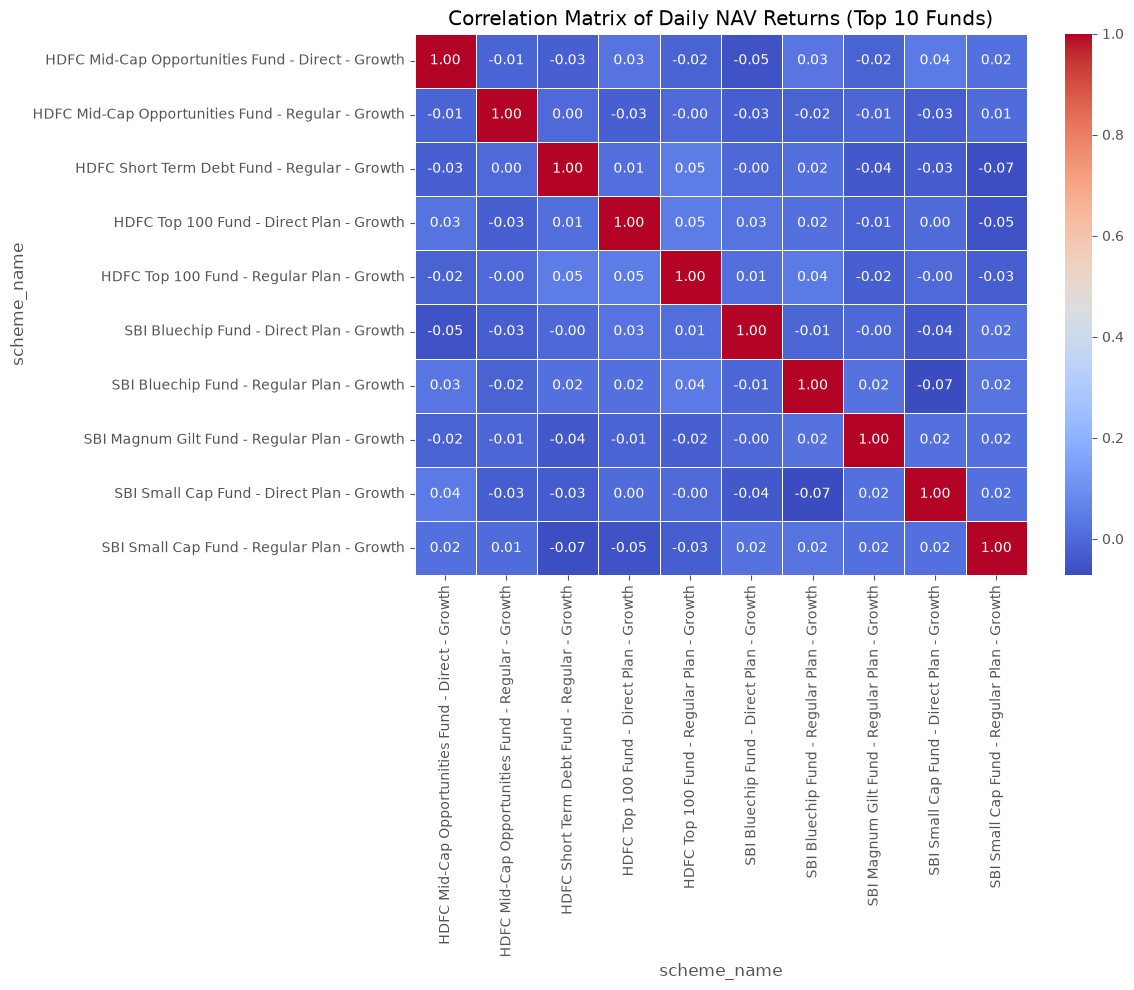

In [35]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (Top 10 Funds)")

plt.tight_layout()

plt.savefig(
    "../reports/nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8

The correlation matrix shows that many large-cap equity funds exhibit strong positive correlations because they are influenced by similar market conditions. Lower correlations among certain schemes suggest diversification benefits, helping investors reduce portfolio risk by combining funds with different return patterns.

# Task 9 – Sector Allocation Donut Chart

This analysis aggregates portfolio holdings across all equity mutual funds to identify the sector-wise allocation. The donut chart highlights which sectors receive the largest share of investments.

In [36]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [37]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [38]:
sector_weight = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weight

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

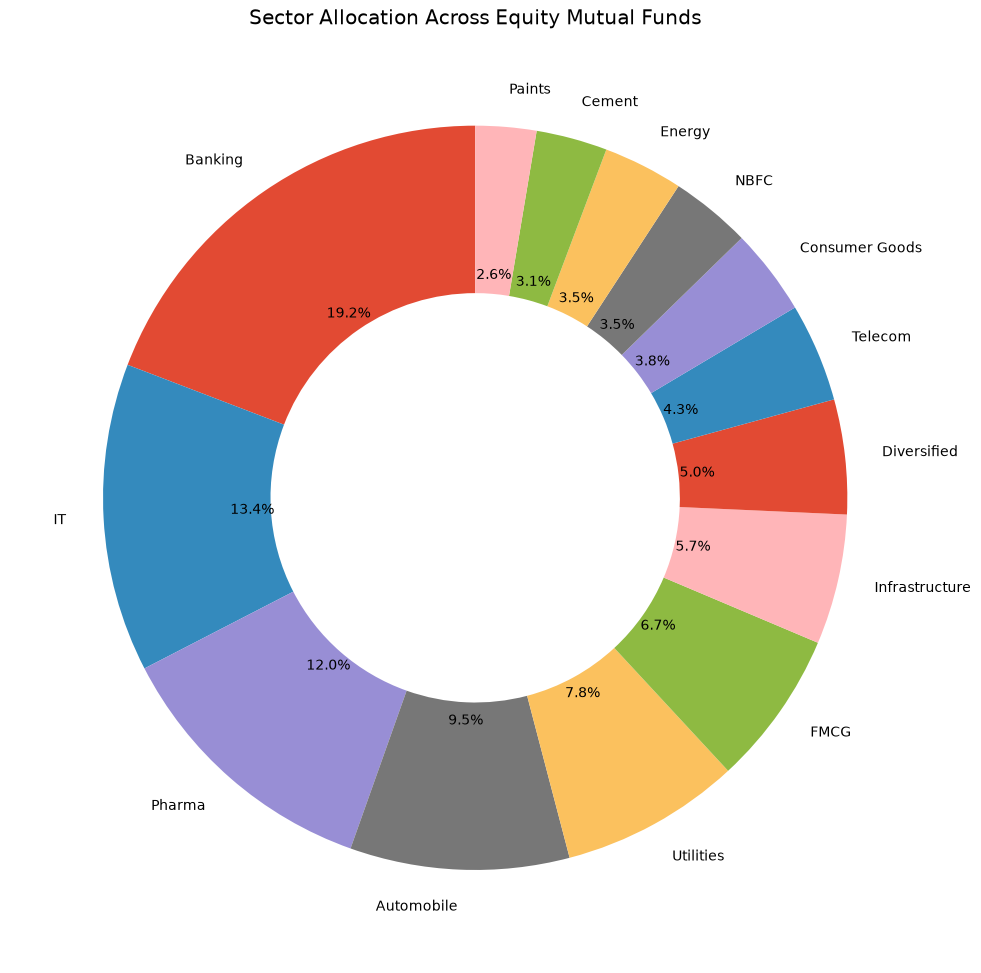

In [39]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weight,
    labels=sector_weight.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.tight_layout()

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 9

The sector allocation analysis indicates that investments are concentrated in a few dominant sectors such as Financial Services, Information Technology, and Healthcare. This reflects the preference of equity mutual funds for sectors with strong long-term growth potential while maintaining diversification across industries.

# Key EDA Findings

1. Mutual fund NAVs showed a generally upward trend between 2022 and 2026, indicating long-term growth.

2. The 2023 market experienced a strong bull run, while 2024 showed periods of market correction.

3. SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore by 2025.

4. Monthly SIP inflows increased consistently and reached an all-time high of ₹31,002 crore in December 2025.

5. Liquid Funds recorded the highest monthly net inflows among all mutual fund categories.

6. Investors aged 26–35 years represented the largest share of mutual fund participants.

7. T30 cities contributed a larger share of investments than B30 cities, highlighting stronger participation from major urban centers.

8. Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025.

9. Most equity mutual funds exhibited strong positive return correlations because they tracked similar market movements.

10. Financial Services, Information Technology, and Healthcare accounted for a significant portion of equity portfolio allocations, demonstrating their importance in diversified mutual fund portfolios.